# Lab - 1 - End-to-End Machine Learning Project 

## Import Libraries

In [ ]:
# Importing necessary libraries
import numpy as np                  # For numerical computations
import pandas as pd                 # For data manipulation using dataframes
import matplotlib.pyplot as plt     # For data visualization
import seaborn as sns               # For data visualization
from sklearn.model_selection import train_test_split  # For splitting the dataset
from sklearn.preprocessing import StandardScaler      # For feature scaling
from sklearn.linear_model import LinearRegression     # For the linear regression model
from sklearn.metrics import mean_squared_error, r2_score  # For evaluating the model

## Load the Dataset

In [ ]:
# Importing the California housing dataset from Scikit-Learn
from sklearn.datasets import fetch_california_housing

# Loading the dataset
data = fetch_california_housing()

# Converting the dataset into a pandas DataFrame for easier manipulation
housing_df = pd.DataFrame(data.data, columns=data.feature_names)

# Adding the target column (housing prices) to the DataFrame
housing_df['MedHouseVal'] = data.target



In [ ]:
# Display the first few rows of the dataset
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Display the last 5 rows of the housing_df DataFrame
housing_df.tail()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [ ]:
# Display the entire housing_df DataFrame
housing_df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
# checking the number of rows and Columns in the data frame
housing_df.shape

(20640, 9)

 ## Preprocessing, Data Exploration and Visualization

In [ ]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
print(housing_df.isnull().sum())  # Should be all zeros

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [ ]:
housing_df["MedHouseVal"].value_counts() #to count how many times each unique value appears in the MedHouseVal column of the California housing dataset.

,count
MedHouseVal,
5.00001,965
1.37500,122
1.62500,117
1.12500,103
1.87500,93
...,...
0.34200,1
0.46200,1
3.52000,1


In [ ]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


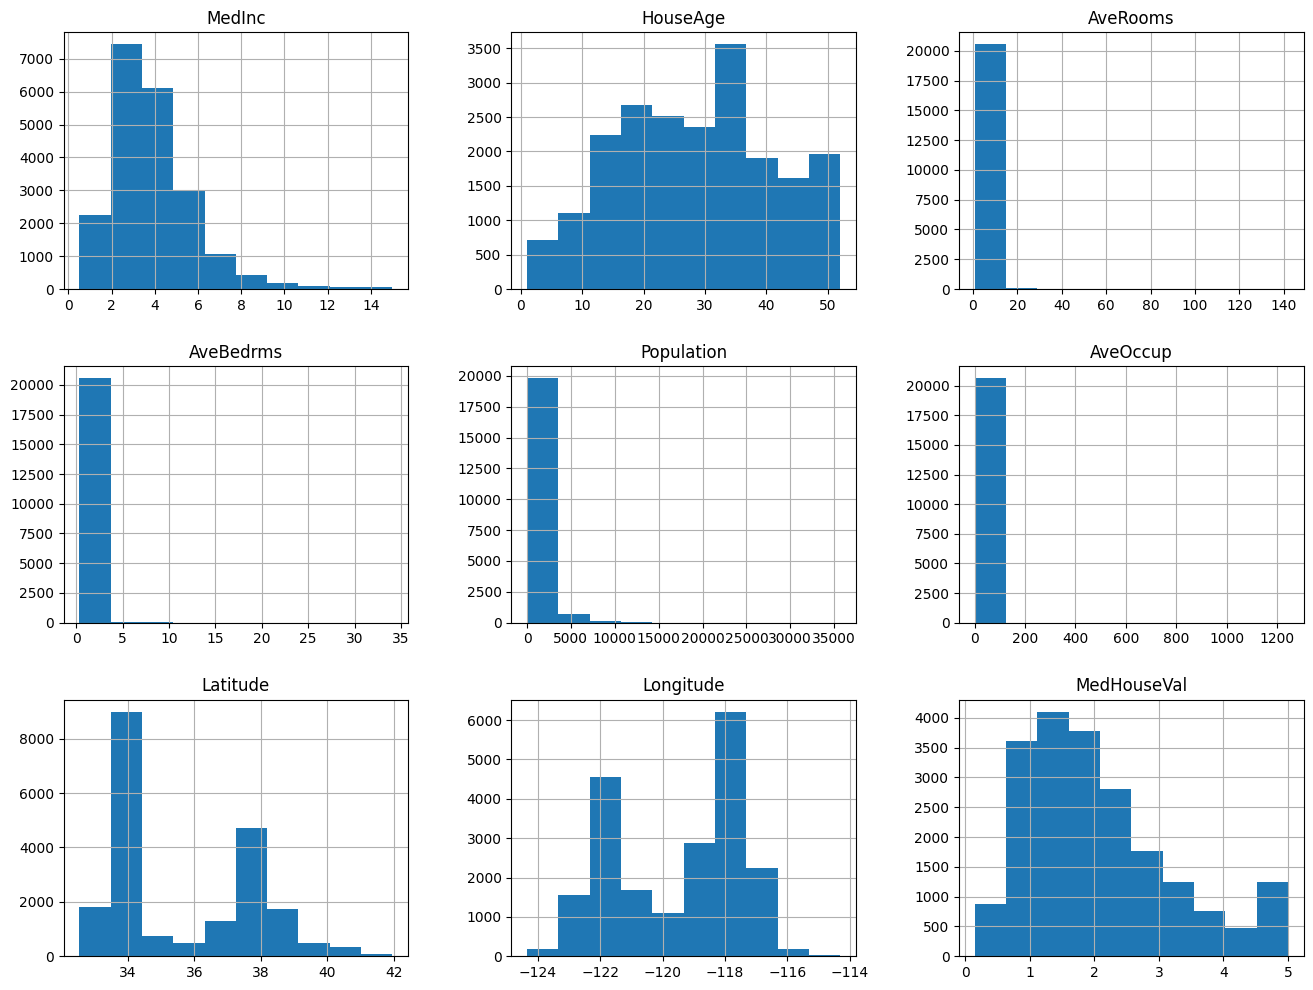

In [ ]:
# Create histograms for each feature in the DataFrame 'data'
# figsize=(10, 8) sets the size of the figure to 10 inches by 8 inches
housing_df.hist(figsize=(16, 12))

# Display the histograms
# plt.show() renders the plots and displays them in the output
plt.show()

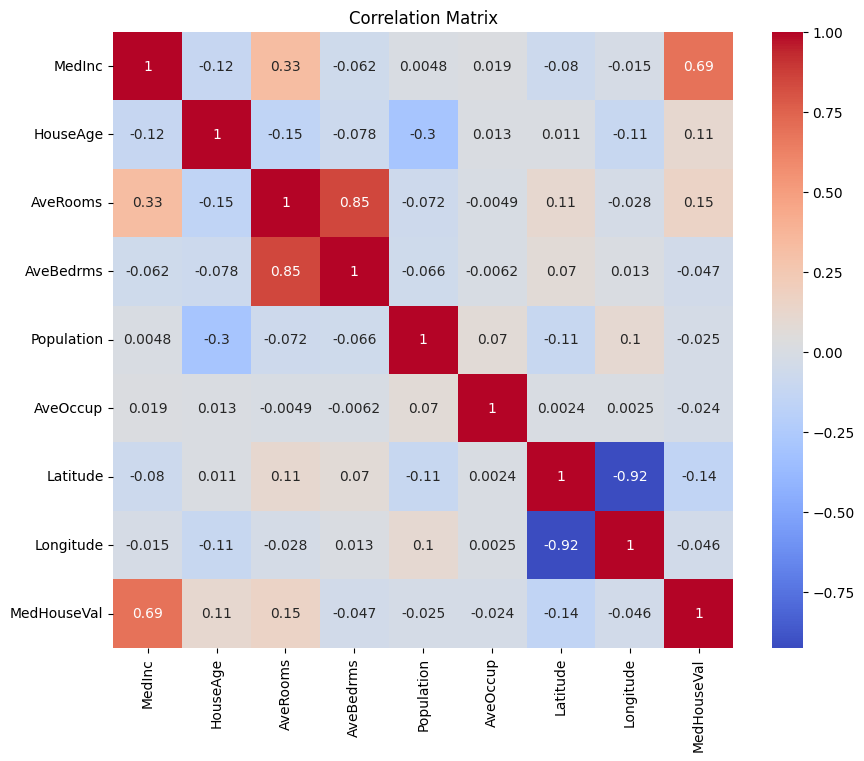

In [ ]:
# Visualizing the correlation matrix to see how features are related to the target variable
corr_matrix = housing_df.corr()

# Using a heatmap to display the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Split into feature and Target

In [ ]:
X = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

In [ ]:
sample_incomplete_rows = housing_df[housing_df.isnull().any(axis=1)].head()
sample_incomplete_rows

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


In [ ]:
# Split the dataset into training and testing sets (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(20640, 8) (16512, 8) (4128, 8)



### Feature scaling




In [ ]:
# Feature scaling to normalize the data (important for regression models)
scaler = StandardScaler()
# Fitting the scaler on the training data and transforming both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training
Linear Regression

In [ ]:
# Initializing the Linear Regression model
model = LinearRegression()

# Training the model on the training data
model.fit(X_train_scaled, y_train)


LinearRegression()

### **Model Evaluation**

In [ ]:
# Making predictions on the train data
y_pred = model.predict(X_train_scaled)

# Calculating the Mean Squared Error (MSE) to evaluate the model's performance
mse = mean_squared_error(y_train, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculating the Root Mean Squared Error (RMSE) for easier interpretation
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

# Calculating the R-squared value to see how well the model explains the variability of the target variable
r2 = r2_score(y_train, y_pred)
print(f"R-squared: {r2}")


Mean Squared Error: 0.5179331255246699
Root Mean Squared Error: 0.7196757085831575
R-squared: 0.6125511913966952


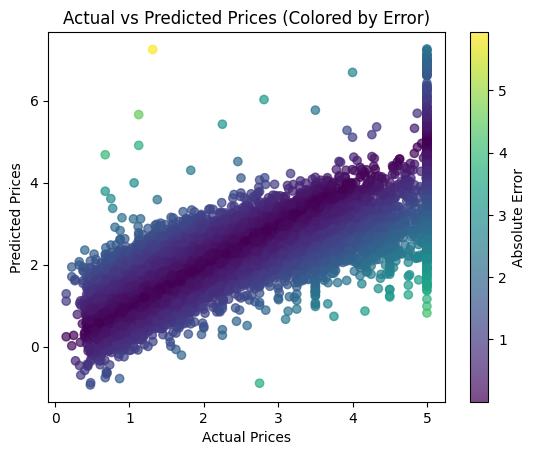

In [ ]:
errors = np.abs(y_train - y_pred)
plt.scatter(y_train, y_pred, c=errors, cmap='viridis', alpha=0.7)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Colored by Error)")
plt.colorbar(label="Absolute Error")
plt.show()


#Polynomial Regression